# Telecom Customer Churn: Data Cleaning & Exploratory Analysis 🧹📊

Companion notebook to [`telecom_churn_retention.ipynb`](telecom_churn_retention.ipynb) — this one covers the preprocessing and exploratory work that happens *before* modeling: fixing hidden type/missingness issues, checking which columns are actually related to churn (visually and statistically), engineering two new features, and preparing a clean, encoded, split dataset.

## Roadmap
1. Visualize missing data
2. Fix column types
3. Handle the 11 missing `TotalCharges` values (and a mutation bug caught along the way)
4. Check for duplicates
5. Drop the identifier column, save a cleaned checkpoint
6. Look at the target distribution
7. Categorical column overview
8. Continuous column overview
9. Correlation heatmap
10. Categorical columns vs. churn
11. Numeric columns vs. churn
12. Chi-square tests — which categorical columns actually matter?
13. Welch's t-tests — which numeric columns actually matter?
14. Feature engineering: `NumServices`, `TenureGroup`
15. Encoding
16. Scaling
17. Stratified train/test split

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind, gaussian_kde
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

SURFACE = "#1a1a19"
INK_PRIMARY = "#ffffff"
INK_SECONDARY = "#c3c2b7"
INK_MUTED = "#898781"
GRIDLINE = "#2c2c2a"
BASELINE = "#383835"
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
CATEGORICAL = ["#3987e5", "#199e70", "#c98500", "#9085e9", "#d03b3b", "#fab219"]

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = BASELINE
plt.rcParams["text.color"] = INK_PRIMARY
plt.rcParams["axes.labelcolor"] = INK_SECONDARY
plt.rcParams["xtick.color"] = INK_MUTED
plt.rcParams["ytick.color"] = INK_MUTED

def style_ax(ax, y_grid=True):
    ax.set_facecolor(SURFACE)
    if y_grid:
        ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.spines["left"].set_color(BASELINE)

def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(f"assets/{name}", dpi=150, facecolor=SURFACE, bbox_inches="tight")

## Step 1 — Visualize Missing Data

Before touching anything, check what's actually missing. `df.isna()` finds nothing — but a quick look at `dtypes` shows `TotalCharges` stored as `object` (text) instead of a number, which is a strong hint that it secretly contains something that isn't numeric.

Raw shape: (7043, 21)

Standard nulls (df.isna().sum()): 0
TotalCharges dtype: object — suspicious for a currency column


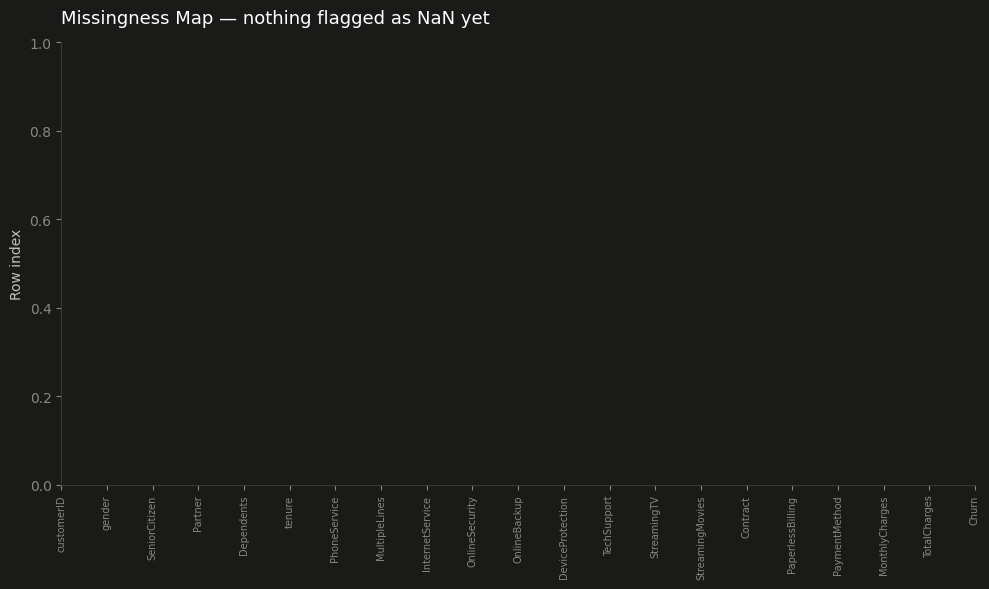

In [2]:
df = pd.read_csv("data/telco_customer_churn.csv")
df.columns = df.columns.str.strip()
print("Raw shape:", df.shape)
print("\nStandard nulls (df.isna().sum()):", int(df.isna().sum().sum()))
print("TotalCharges dtype:", df["TotalCharges"].dtype, "— suspicious for a currency column")

fig, ax = plt.subplots(figsize=(10, 6), facecolor=SURFACE)
style_ax(ax, y_grid=False)
missing_mask = df.isna()
for i, col in enumerate(df.columns):
    ys = np.where(missing_mask[col].values)[0]
    if len(ys):
        ax.scatter([i] * len(ys), ys, s=4, color=STATUS["critical"], zorder=3)
ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=90, fontsize=7, color=INK_MUTED)
ax.set_ylabel("Row index")
ax.set_title("Missingness Map — nothing flagged as NaN yet", fontsize=13, color=INK_PRIMARY, loc="left", pad=14)
savefig(fig, "prep_missingness_map.png")
plt.show()

**Key insight:** missing data doesn't always look like `NaN`. Here it's disguised as the wrong dtype — a column that should be numeric but is stored as text, almost always because a handful of rows contain a non-numeric value like a blank space.

## Step 2 — Fix Column Types

Convert `TotalCharges` to numeric (anything non-numeric becomes a proper `NaN`), and recode `SeniorCitizen` from `0`/`1` to `"No"`/`"Yes"` so it matches the style of every other Yes/No column.

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].astype(str).str.strip(), errors="coerce")
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

n_missing = df["TotalCharges"].isna().sum()
missing_rows = df[df["TotalCharges"].isna()]
print(f"TotalCharges is now {df['TotalCharges'].dtype}. Missing values revealed: {n_missing}")
print("All missing rows have tenure == 0:", (missing_rows["tenure"] == 0).all())
print("None of them churned:", (missing_rows["Churn"] == "No").all())

TotalCharges is now float64. Missing values revealed: 11
All missing rows have tenure == 0: True
None of them churned: True


**What this means:** all 11 rows with missing `TotalCharges` are brand-new customers (`tenure == 0`) who hadn't been billed yet — not a data quality problem, a predictable consequence of how the column is defined. None of them churned either, which matters for Step 3.

## Step 3 — Drop vs. Median vs. Impute (and a mutation bug)

Three strategies for the 11 missing `TotalCharges` values: **drop** the rows, fill with the column **median**, or **impute** an estimate (`MonthlyCharges × tenure`, since `TotalCharges` should roughly equal what a customer has paid so far). The first version of this function had a bug worth keeping as a lesson: it mutated the caller's DataFrame in place instead of working on a private copy, so calling it twice in a row (`'impute'` then `'median'`) silently corrupted the second call — the missing values were already filled in by the first.

In [4]:
def handle_missing_totalcharges_buggy(data, strategy):
    # BUG: mutates the caller's DataFrame in place
    if strategy == "drop":
        data = data.dropna(subset=["TotalCharges"])
    elif strategy == "median":
        data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())
    elif strategy == "impute":
        est = data["MonthlyCharges"] * data["tenure"]
        data["TotalCharges"] = data["TotalCharges"].fillna(est)
    return data

def handle_missing_totalcharges(data, strategy):
    data = data.copy()  # fix: never mutate the caller's frame
    if strategy == "drop":
        data = data.dropna(subset=["TotalCharges"])
    elif strategy == "median":
        data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())
    elif strategy == "impute":
        est = data["MonthlyCharges"] * data["tenure"]
        data["TotalCharges"] = data["TotalCharges"].fillna(est)
    return data

demo = df.copy()
before = demo["TotalCharges"].isna().sum()
_ = handle_missing_totalcharges_buggy(demo, "impute")
after_impute_call = demo["TotalCharges"].isna().sum()
print(f"Buggy version — missing before: {before}, after calling with 'impute': {after_impute_call}")
print("The ORIGINAL frame got mutated even though we never reassigned it — that's the bug.")

# Use the fixed version going forward, choosing "impute" as the final strategy
df = handle_missing_totalcharges(df, "impute")
print("\nFixed version — missing TotalCharges after impute:", df["TotalCharges"].isna().sum())

Buggy version — missing before: 11, after calling with 'impute': 0
The ORIGINAL frame got mutated even though we never reassigned it — that's the bug.

Fixed version — missing TotalCharges after impute: 0


**Why impute, not drop:** dropping 11 rows out of 7,043 wouldn't hurt the model, but they're not random — they're a clean, identifiable subgroup (day-one customers) that a real churn model will need to score too. Imputing with `MonthlyCharges × tenure` keeps them in the dataset with a value on the correct scale, since `tenure == 0` means the honest answer for `TotalCharges` is close to zero anyway.

## Step 4 — Duplicates

In [5]:
n_dupes = df.duplicated().sum()
print("Fully duplicated rows:", n_dupes)

Fully duplicated rows: 0


## Step 5 — Drop the Identifier, Save a Checkpoint

`customerID` is a unique identifier — by definition it can't help predict anything, since no two customers share one. Dropping it now and saving a checkpoint keeps every later step working from the same clean base.

In [6]:
df = df.drop(columns=["customerID"])
df.to_csv("data/precleaned-Telco-Customer-Churn.csv", index=False)
print("Cleaned shape:", df.shape)

Cleaned shape: (7043, 20)


## Step 6 — Target Distribution

How balanced is the thing we're trying to predict?

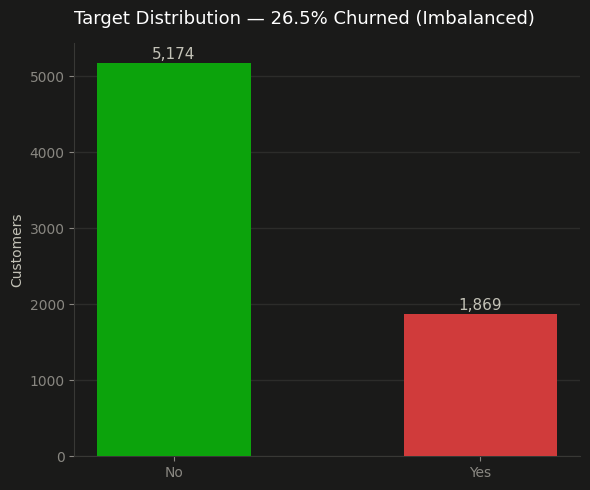

In [7]:
churn_counts = df["Churn"].value_counts()
churn_rate = (df["Churn"] == "Yes").mean()

fig, ax = plt.subplots(figsize=(6, 5), facecolor=SURFACE)
style_ax(ax)
bars = ax.bar(churn_counts.index, churn_counts.values, color=[STATUS["good"], STATUS["critical"]], width=0.5, zorder=3)
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 60, f"{val:,}", ha="center", fontsize=11, color=INK_SECONDARY)
ax.set_ylabel("Customers")
ax.set_title(f"Target Distribution — {churn_rate:.1%} Churned (Imbalanced)", fontsize=13, color=INK_PRIMARY, loc="left", pad=14)
savefig(fig, "prep_target_distribution.png")
plt.show()

**5,174 stayed vs. 1,869 churned — a 26.5% churn rate.** This is an imbalanced target: a model that always predicts "No" is already "right" ~73% of the time without learning anything, so accuracy alone can't be trusted to judge a model here (the same trap the modeling notebook calls out explicitly in Step 3).

## Step 7 — Categorical Column Overview

A grid of bar charts across every categorical column at once — a fast way to scan for rare categories, dominant categories, or columns that look suspiciously uniform.

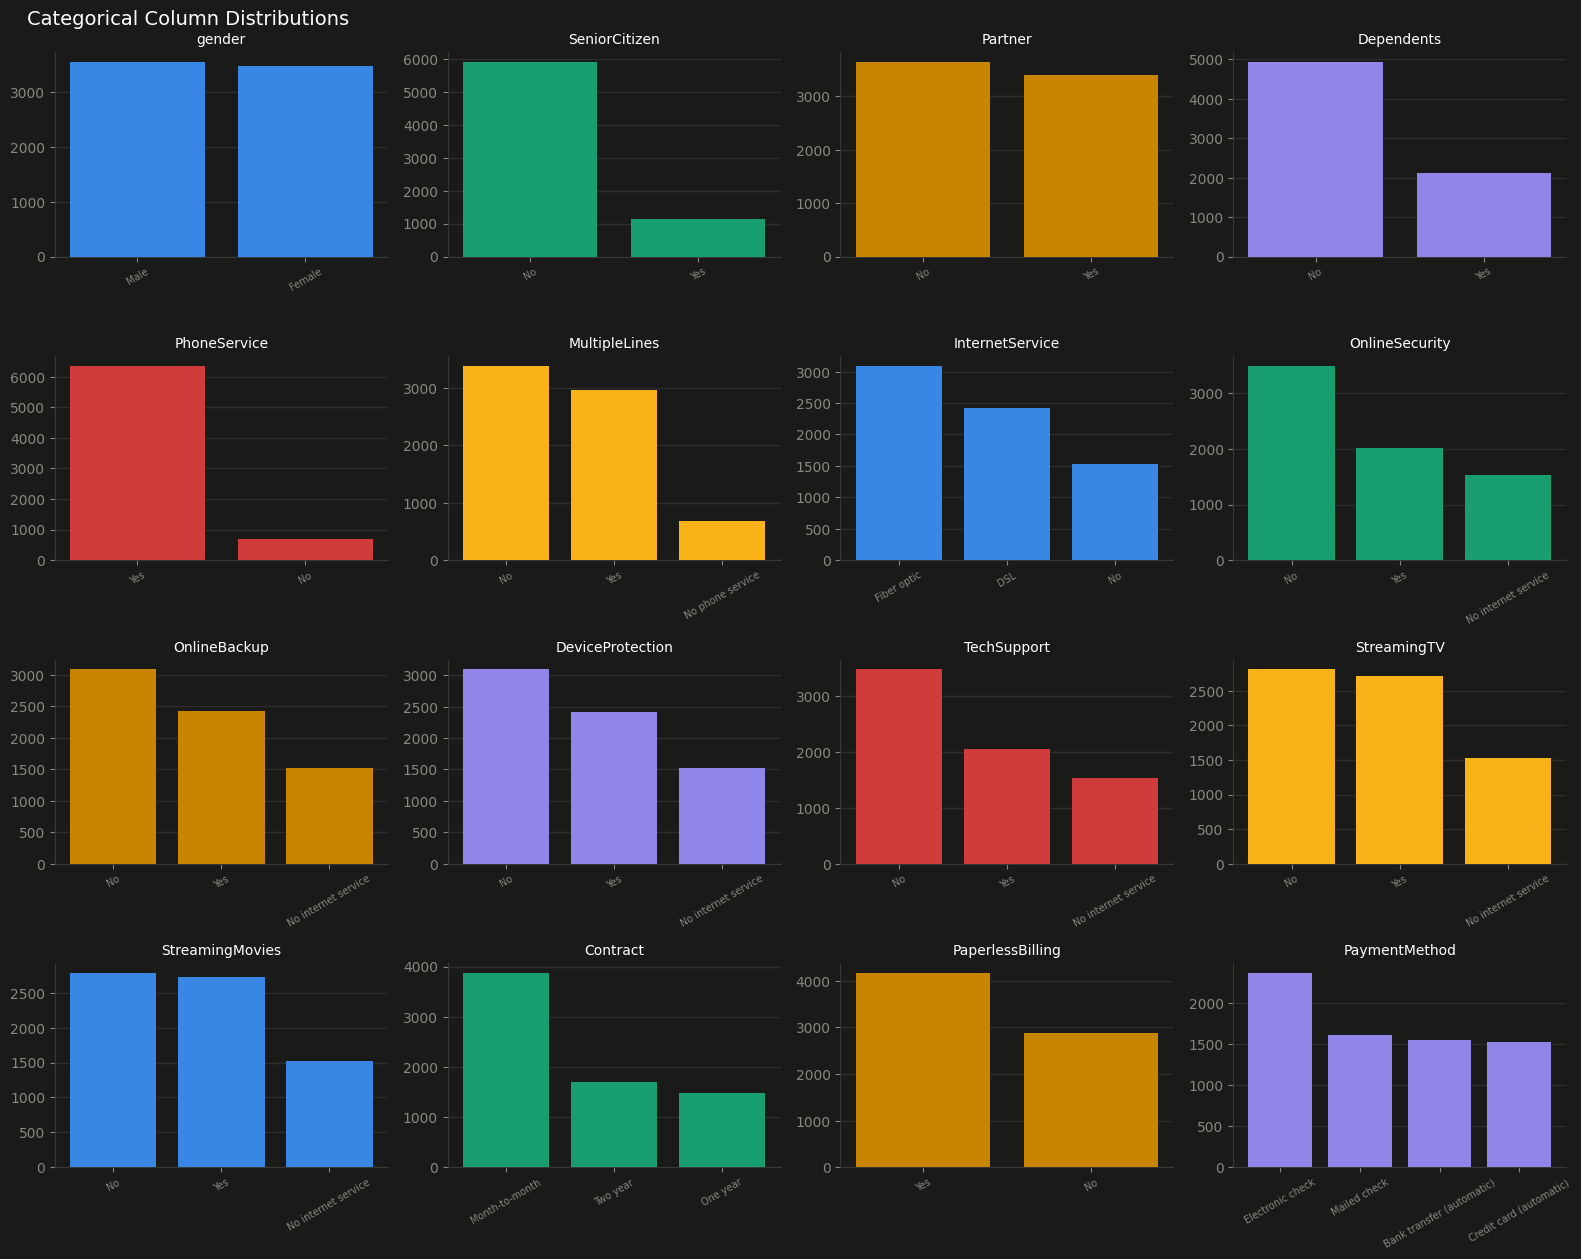

In [8]:
cat_cols = [c for c in df.select_dtypes(include="object").columns if c != "Churn"]
n_grid_cols = 4
n_grid_rows = int(np.ceil(len(cat_cols) / n_grid_cols))
fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(16, 3.2 * n_grid_rows), facecolor=SURFACE)
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ax = axes[i]
    style_ax(ax)
    vc = df[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values, color=CATEGORICAL[i % len(CATEGORICAL)], zorder=3)
    ax.set_title(col, fontsize=10, color=INK_PRIMARY)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
for j in range(len(cat_cols), len(axes)):
    axes[j].axis("off")
fig.suptitle("Categorical Column Distributions", fontsize=14, color=INK_PRIMARY, x=0.02, ha="left")
savefig(fig, "prep_categorical_distributions.png")
plt.show()

## Step 8 — Continuous Column Overview

For each numeric column: a histogram with a KDE curve overlaid (a smoothed estimate of the underlying distribution), plus a boxplot for a quick read on spread and outliers.

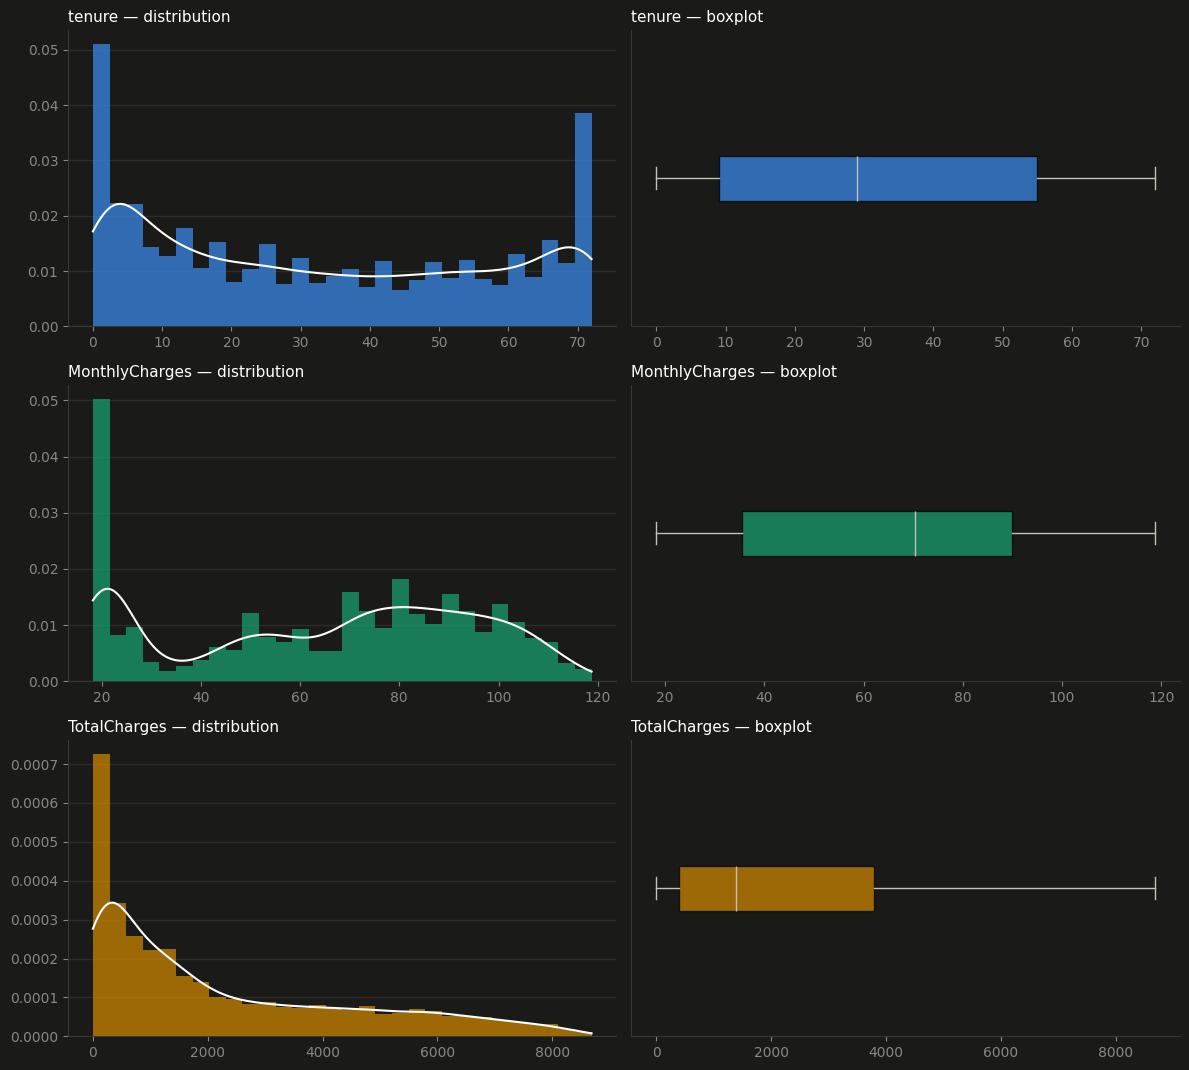

tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963235
dtype: float64


In [9]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3.6 * len(num_cols)), facecolor=SURFACE)
for i, col in enumerate(num_cols):
    ax_hist, ax_box = axes[i]
    style_ax(ax_hist)
    style_ax(ax_box)
    vals = df[col].dropna().values
    ax_hist.hist(vals, bins=30, color=CATEGORICAL[i], alpha=0.75, zorder=3, density=True)
    kde = gaussian_kde(vals)
    xs = np.linspace(vals.min(), vals.max(), 200)
    ax_hist.plot(xs, kde(xs), color=INK_PRIMARY, linewidth=1.5, zorder=4)
    ax_hist.set_title(f"{col} — distribution", fontsize=11, color=INK_PRIMARY, loc="left")
    bp = ax_box.boxplot(vals, vert=False, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor(CATEGORICAL[i]); patch.set_alpha(0.75)
    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_color(INK_SECONDARY)
    ax_box.set_yticks([])
    ax_box.set_title(f"{col} — boxplot", fontsize=11, color=INK_PRIMARY, loc="left")
savefig(fig, "prep_continuous_distributions.png")
plt.show()

print(df[num_cols].skew())

`tenure` is right-skewed (lots of very new customers), `MonthlyCharges` is roughly bell-shaped, and `TotalCharges` is heavily right-skewed — expected, since most customers are early in their tenure and haven't accumulated a large total yet.

## Step 9 — Correlation Heatmap

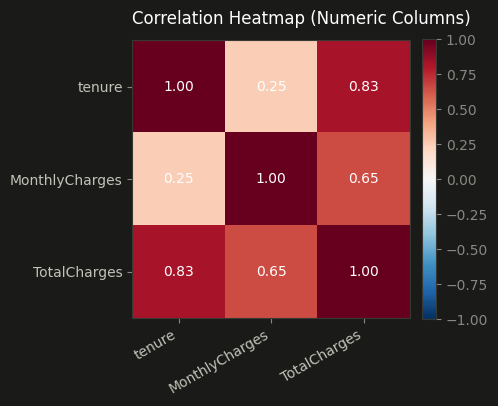

In [10]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4.5), facecolor=SURFACE)
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=30, ha="right", color=INK_SECONDARY)
ax.set_yticklabels(num_cols, color=INK_SECONDARY)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr.values[i, j]) > 0.5 else INK_PRIMARY, fontsize=10)
ax.set_title("Correlation Heatmap (Numeric Columns)", fontsize=12, color=INK_PRIMARY, loc="left", pad=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
savefig(fig, "prep_correlation_heatmap.png")
plt.show()

`tenure` and `TotalCharges` are strongly correlated (0.83 — longer-tenured customers have simply paid more in total), `MonthlyCharges`/`TotalCharges` are moderately correlated (0.65), and `tenure`/`MonthlyCharges` are weakly correlated (0.25). Nothing here is redundant enough to drop outright, but it's the kind of check that would catch a multicollinearity problem before it reaches the model — the same category of bug the modeling notebook found and fixed in the raw service columns.

## Step 10 — Categorical Columns vs. Churn

For a given categorical column, compute the churn rate *within each category* and plot it. A column where the churn rate barely moves across categories is a column carrying little predictive signal.

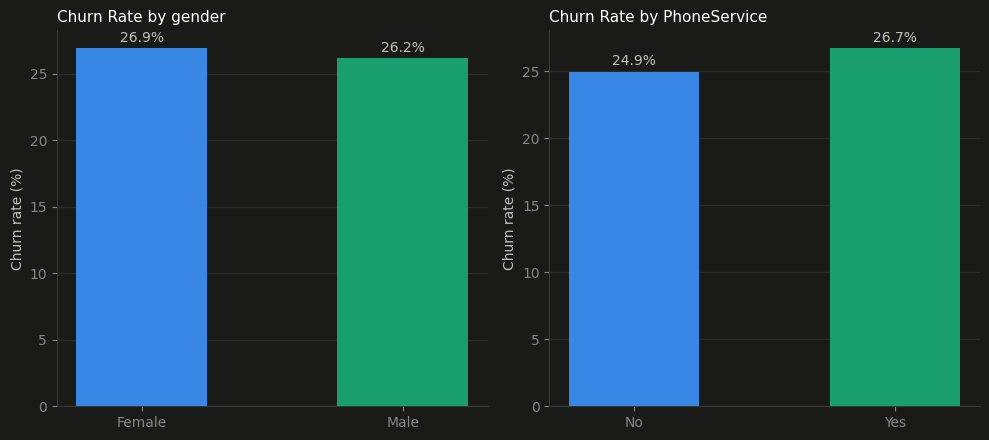

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), facecolor=SURFACE)
for ax, col in zip(axes, ["gender", "PhoneService"]):
    style_ax(ax)
    rates = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean()) * 100
    bars = ax.bar(rates.index.astype(str), rates.values, color=CATEGORICAL[:len(rates)], width=0.5, zorder=3)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"{val:.1f}%", ha="center", fontsize=10, color=INK_SECONDARY)
    ax.set_title(f"Churn Rate by {col}", fontsize=11, color=INK_PRIMARY, loc="left")
    ax.set_ylabel("Churn rate (%)")
savefig(fig, "prep_categorical_vs_churn.png")
plt.show()

`gender` (26.9% women vs. 26.2% men) and `PhoneService` (24.9% vs. 26.7%) both look essentially flat across categories — an early visual hint that neither carries real signal. Step 12 tests that impression statistically instead of eyeballing it.

## Step 11 — Numeric Columns vs. Churn

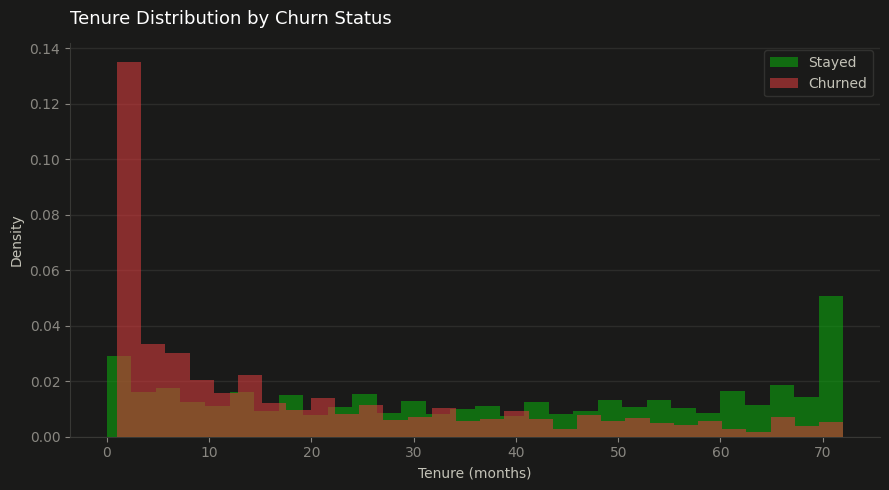

In [12]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=SURFACE)
style_ax(ax)
stayed = df.loc[df["Churn"] == "No", "tenure"]
churned = df.loc[df["Churn"] == "Yes", "tenure"]
ax.hist(stayed, bins=30, alpha=0.6, label="Stayed", color=STATUS["good"], zorder=3, density=True)
ax.hist(churned, bins=30, alpha=0.6, label="Churned", color=STATUS["critical"], zorder=3, density=True)
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Density")
ax.set_title("Tenure Distribution by Churn Status", fontsize=13, color=INK_PRIMARY, loc="left", pad=14)
ax.legend(facecolor=SURFACE, edgecolor=BASELINE, labelcolor=INK_SECONDARY)
savefig(fig, "prep_tenure_vs_churn.png")
plt.show()

Churned customers cluster heavily under 12 months of tenure; customers who stayed are spread across the full range, with a second spike near 70+ months (long-time loyal customers). A strong visual signal that `tenure` matters — confirmed statistically in Step 13.

## Step 12 — Chi-Square Tests

For every categorical column, a chi-square test of independence checks whether it's really unrelated to churn or whether Step 10's visual impression holds up statistically. `p < 0.05` → keep the column; `p ≥ 0.05` → the observed difference is small enough to be random chance, safe to drop.

In [13]:
chi_results = {}
for col in cat_cols:
    table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, exp = chi2_contingency(table)
    chi_results[col] = p

for col, p in sorted(chi_results.items(), key=lambda kv: -kv[1]):
    flag = "  <-- DROP (p >= 0.05)" if p >= 0.05 else ""
    print(f"{col:20s} p = {p:.4g}{flag}")

drop_cols_chi = [c for c, p in chi_results.items() if p >= 0.05]
df = df.drop(columns=drop_cols_chi)
print("\nDropped:", drop_cols_chi)

gender               p = 0.4866  <-- DROP (p >= 0.05)
PhoneService         p = 0.3388  <-- DROP (p >= 0.05)
MultipleLines        p = 0.003464
Partner              p = 2.14e-36
SeniorCitizen        p = 1.51e-36
Dependents           p = 4.925e-43
PaperlessBilling     p = 4.073e-58
StreamingTV          p = 5.529e-82
StreamingMovies      p = 2.668e-82
DeviceProtection     p = 5.505e-122
OnlineBackup         p = 2.08e-131
PaymentMethod        p = 3.682e-140
InternetService      p = 9.572e-160
TechSupport          p = 1.443e-180
OnlineSecurity       p = 2.661e-185
Contract             p = 5.863e-258

Dropped: ['gender', 'PhoneService']


`gender` (p ≈ 0.49) and `PhoneService` (p ≈ 0.34) both fail the test exactly as Step 10 suggested — dropped. Every other categorical column has a p-value effectively at zero, meaning all of them are genuinely related to churn.

## Step 13 — Welch's t-Tests

The numeric equivalent of Step 12: split customers by churn status and compare the *average* value of each numeric column between the two groups. Welch's version of the t-test (`equal_var=False`) is used because it doesn't assume both groups have equal variance — a safer default here, since churners and non-churners are very different-sized, differently-shaped groups.

In [14]:
ttest_results = {}
for col in num_cols:
    churned_vals = df.loc[df["Churn"] == "Yes", col].dropna()
    stayed_vals = df.loc[df["Churn"] == "No", col].dropna()
    tstat, p = ttest_ind(churned_vals, stayed_vals, equal_var=False)
    ttest_results[col] = p
    print(f"{col:20s} p = {p:.4g}")

tenure               p = 1.195e-232
MonthlyCharges       p = 8.592e-73
TotalCharges         p = 5.903e-75


All three p-values are effectively zero — `tenure`, `MonthlyCharges`, and `TotalCharges` all have genuinely, significantly different averages between churners and non-churners. All three are useful predictors.

## Step 14 — Feature Engineering: `NumServices` and `TenureGroup`

Two engineered features that reshape existing information into a form a model can use more directly:

- **`NumServices`** — a count of how many optional services each customer subscribes to (multiple lines, internet, online security/backup, device protection, tech support, streaming TV/movies), plus one point just for having internet service at all.
- **`TenureGroup`** — `tenure` bucketed into five phases (`0-12`, `13-24`, `25-48`, `49-60`, `60+` months), since customer behavior tends to shift in phases rather than change smoothly month to month.

The original columns used to build these (the individual service columns and raw `tenure`) are dropped afterward to avoid redundancy.

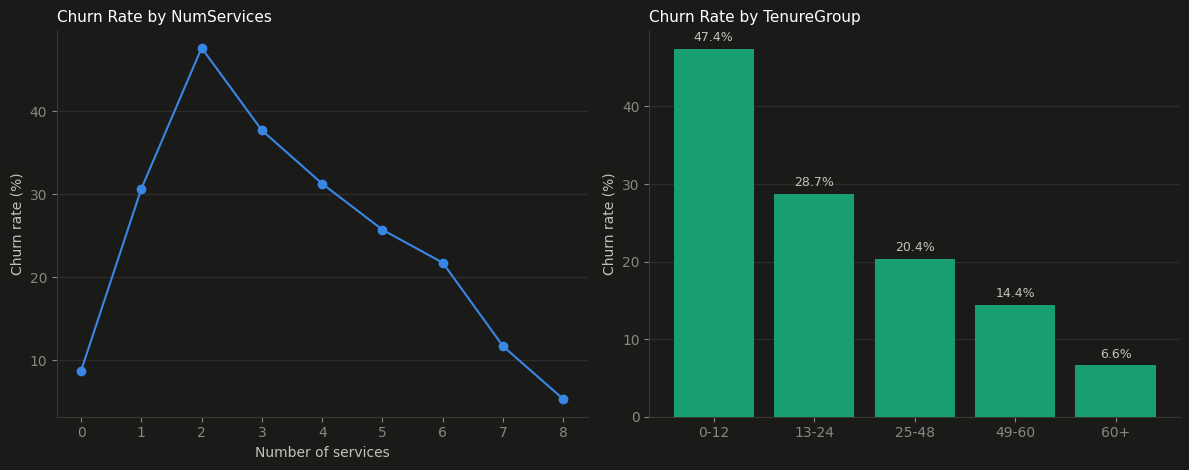

TenureGroup chi-square p-value: 1.534e-187
Dropped after engineering (now redundant): ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'tenure']
Shape after feature engineering: (7043, 12)


In [15]:
service_cols = [c for c in [
    "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
] if c in df.columns]

df["NumServices"] = df[service_cols].apply(lambda row: (row == "Yes").sum(), axis=1)
df["NumServices"] += (df["InternetService"] != "No").astype(int)

bins = [-1, 12, 24, 48, 60, np.inf]
labels = ["0-12", "13-24", "25-48", "49-60", "60+"]
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), facecolor=SURFACE)
style_ax(axes[0])
ns_rate = df.groupby("NumServices")["Churn"].apply(lambda s: (s == "Yes").mean()) * 100
axes[0].plot(ns_rate.index, ns_rate.values, marker="o", color=CATEGORICAL[0], zorder=3)
axes[0].set_title("Churn Rate by NumServices", fontsize=11, color=INK_PRIMARY, loc="left")
axes[0].set_xlabel("Number of services"); axes[0].set_ylabel("Churn rate (%)")

style_ax(axes[1])
tg_rate = df.groupby("TenureGroup", observed=True)["Churn"].apply(lambda s: (s == "Yes").mean()) * 100
tg_rate = tg_rate.reindex(labels)
bars = axes[1].bar(tg_rate.index.astype(str), tg_rate.values, color=CATEGORICAL[1], zorder=3)
for bar, val in zip(bars, tg_rate.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}%", ha="center", fontsize=9, color=INK_SECONDARY)
axes[1].set_title("Churn Rate by TenureGroup", fontsize=11, color=INK_PRIMARY, loc="left")
axes[1].set_ylabel("Churn rate (%)")
savefig(fig, "prep_engineered_features.png")
plt.show()

table = pd.crosstab(df["TenureGroup"], df["Churn"])
chi2, p_tenuregroup, dof, exp = chi2_contingency(table)
print(f"TenureGroup chi-square p-value: {p_tenuregroup:.4g}")

drop_for_engineering = [c for c in service_cols + ["tenure"] if c in df.columns]
df = df.drop(columns=drop_for_engineering)
print("Dropped after engineering (now redundant):", drop_for_engineering)
df.to_csv("data/featured-Telco-Customer-Churn.csv", index=False)
print("Shape after feature engineering:", df.shape)

**`NumServices` is not simply "fewer is safer, more is safer" — it peaks in the middle.** Churn rises sharply from 0 services (8.7% churn) to 2 services (47.7% churn, the single riskiest group), then falls steadily as service count keeps climbing, down to 5.3% at 8 services. Zero-service customers are likely on minimal, low-cost plans with little to be dissatisfied about; 2-service customers look like the still-evaluating, price-sensitive middle; and heavily bundled customers (6+ services) have a lot to lose by switching providers, which shows up directly as loyalty. `TenureGroup` shows a cleaner, monotonic pattern: churn drops from 47.4% in the first year to 6.6% at 60+ months, and a chi-square test confirms an extremely strong relationship with churn (p ≈ 1.5 × 10⁻¹⁸⁷).

## Step 15 — Encoding

Models need numbers, not text. Different column types get different encoders:

- **`Churn`** (target): `LabelEncoder` → `No = 0`, `Yes = 1`.
- **Simple Yes/No columns** (`Partner`, `Dependents`, `PaperlessBilling`, `SeniorCitizen`): `OrdinalEncoder` with categories fixed explicitly (`[["No", "Yes"]]`) rather than auto-detected, so the encoding is reproducible regardless of what order values happen to appear in the data.
- **Multi-category columns** (`Contract`, `PaymentMethod`, `InternetService`): one-hot encoding with the first category dropped — assigning a single number would falsely imply an order (e.g. "Two year contract > One year contract"), which isn't true.
- **`TenureGroup`**: `OrdinalEncoder`, but this one *does* have a genuine order (`0-12 < 13-24 < ... < 60+`), so a single ordered number is the right shape here, unlike `Contract`/`PaymentMethod`.

In [16]:
df["Churn"] = LabelEncoder().fit_transform(df["Churn"])  # No=0, Yes=1

binary_cols = ["Partner", "Dependents", "PaperlessBilling", "SeniorCitizen"]
for c in binary_cols:
    df[c] = OrdinalEncoder(categories=[["No", "Yes"]]).fit_transform(df[[c]])

onehot_cols = ["Contract", "PaymentMethod", "InternetService"]
ohe = OneHotEncoder(drop="first", sparse_output=False)
ohe_arr = ohe.fit_transform(df[onehot_cols])
ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(onehot_cols), index=df.index)
df = pd.concat([df.drop(columns=onehot_cols), ohe_df], axis=1)

df["TenureGroup"] = OrdinalEncoder(categories=[["0-12", "13-24", "25-48", "49-60", "60+"]]) \
    .fit_transform(df[["TenureGroup"]].astype(str))

print("Columns after encoding:", df.shape[1])

Columns after encoding: 16


## Step 16 — Feature Scaling

`MonthlyCharges` ranges roughly 20–120; `TotalCharges` ranges roughly 0–8,700 — very different scales. Distance- and gradient-sensitive models would otherwise treat the larger-numbered column as more important purely because of its scale. `StandardScaler` rescales both to mean 0, standard deviation 1.

In [17]:
scale_cols = ["MonthlyCharges", "TotalCharges"]
df[scale_cols] = StandardScaler().fit_transform(df[scale_cols])
print(df[scale_cols].agg(["mean", "std"]))

      MonthlyCharges  TotalCharges
mean   -6.406285e-17 -3.783239e-17
std     1.000071e+00  1.000071e+00


## Step 17 — Stratified Train/Test Split

Hold back 20% of the data the model never trains on, so we can check it actually generalizes. A plain random split could accidentally over- or under-represent churners in the test set by chance, since they're already a minority (~27%). Stratified sampling preserves the churn rate in both splits.

In [18]:
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape[0]} rows, churn rate {y_train.mean():.2%}")
print(f"Test:  {X_test.shape[0]} rows, churn rate {y_test.mean():.2%}")
print(f"Full:  {len(y)} rows, churn rate {y.mean():.2%}")

Train: 5634 rows, churn rate 26.54%
Test:  1409 rows, churn rate 26.54%
Full:  7043 rows, churn rate 26.54%


## Conclusion

The raw dataset started with a disguised missingness problem (a numeric column stored as text), 11 day-one customers with genuinely missing `TotalCharges`, and no visibility into which columns actually relate to churn. By the end of this notebook: `TotalCharges` is clean and imputed, `gender` and `PhoneService` are confirmed statistically irrelevant and dropped, `tenure` has been reshaped into a phase-based `TenureGroup`, a new `NumServices` feature captures a non-obvious hump-shaped churn relationship, and the dataset is fully encoded, scaled, and split — ready for the modeling work in [`telecom_churn_retention.ipynb`](telecom_churn_retention.ipynb).